!pip install text-similarity-br

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# ENTRADA
# ══════════════════════════════════════════════════════════════════════════════
input_text = "android motorola pro"

input_text = "iphone 17 pro"

comp_texts = [
    "iphone 13 pro",
    "iphone pro 13",
    "android sansumg 11 pro",
    "android motorola edge",
]
all_texts = [input_text] + comp_texts

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# PASSO 1 — Vocabulário (bag of words)
# ══════════════════════════════════════════════════════════════════════════════
vocab = sorted(set(w for t in all_texts for w in t.lower().split()))
print(f"Vocabulário ({len(vocab)} termos): {vocab}\n")

# ══════════════════════════════════════════════════════════════════════════════
# PASSO 2 — Vetorização por contagem de termos
# ══════════════════════════════════════════════════════════════════════════════
def vectorize(text: str) -> np.ndarray:
    words = text.lower().split()
    return np.array([words.count(w) for w in vocab], dtype=float)

vectors = {t: vectorize(t) for t in all_texts}

for text, vec in vectors.items():
    print(f"  '{text}'\n   → {vec}\n")

# ══════════════════════════════════════════════════════════════════════════════
# PASSO 3 — Similaridade de cosseno (puro NumPy)
# ══════════════════════════════════════════════════════════════════════════════
def cosine_similarity(u: np.ndarray, v: np.ndarray) -> float:
    dot    = np.dot(u, v)               # produto escalar
    norm_u = np.linalg.norm(u)          # ||u||
    norm_v = np.linalg.norm(v)          # ||v||
    if norm_u == 0 or norm_v == 0:
        return 0.0
    return float(dot / (norm_u * norm_v))

Vocabulário (9 termos): ['11', '13', '17', 'android', 'edge', 'iphone', 'motorola', 'pro', 'sansumg']

  'iphone 17 pro'
   → [0. 0. 1. 0. 0. 1. 0. 1. 0.]

  'iphone 13 pro'
   → [0. 1. 0. 0. 0. 1. 0. 1. 0.]

  'iphone pro 13'
   → [0. 1. 0. 0. 0. 1. 0. 1. 0.]

  'android sansumg 11 pro'
   → [1. 0. 0. 1. 0. 0. 0. 1. 1.]

  'android motorola edge'
   → [0. 0. 0. 1. 1. 0. 1. 0. 0.]



In [7]:
v_in    = vectors[input_text]
results = []
print("=" * 55)
print(f"  Input: '{input_text}'")
print("=" * 55)
for comp in comp_texts:
    v_c   = vectors[comp]
    dot   = np.dot(v_in, v_c)
    norm_i = np.linalg.norm(v_in)
    norm_c = np.linalg.norm(v_c)
    sim   = cosine_similarity(v_in, v_c)
    angle = np.degrees(np.arccos(np.clip(sim, -1, 1)))
    results.append((comp, sim, angle))
    print(f"\n  vs '{comp}'")
    print(f"     dot = {dot:.2f}  ||input|| = {norm_i:.4f}  ||comp|| = {norm_c:.4f}")
    print(f"     cos(θ) = {sim:.4f}   θ = {angle:.2f}°")

sims = [r[1] for r in results]

  Input: 'iphone 17 pro'

  vs 'iphone 13 pro'
     dot = 2.00  ||input|| = 1.7321  ||comp|| = 1.7321
     cos(θ) = 0.6667   θ = 48.19°

  vs 'iphone pro 13'
     dot = 2.00  ||input|| = 1.7321  ||comp|| = 1.7321
     cos(θ) = 0.6667   θ = 48.19°

  vs 'android sansumg 11 pro'
     dot = 1.00  ||input|| = 1.7321  ||comp|| = 2.0000
     cos(θ) = 0.2887   θ = 73.22°

  vs 'android motorola edge'
     dot = 0.00  ||input|| = 1.7321  ||comp|| = 1.7321
     cos(θ) = 0.0000   θ = 90.00°



Gráfico salvo!


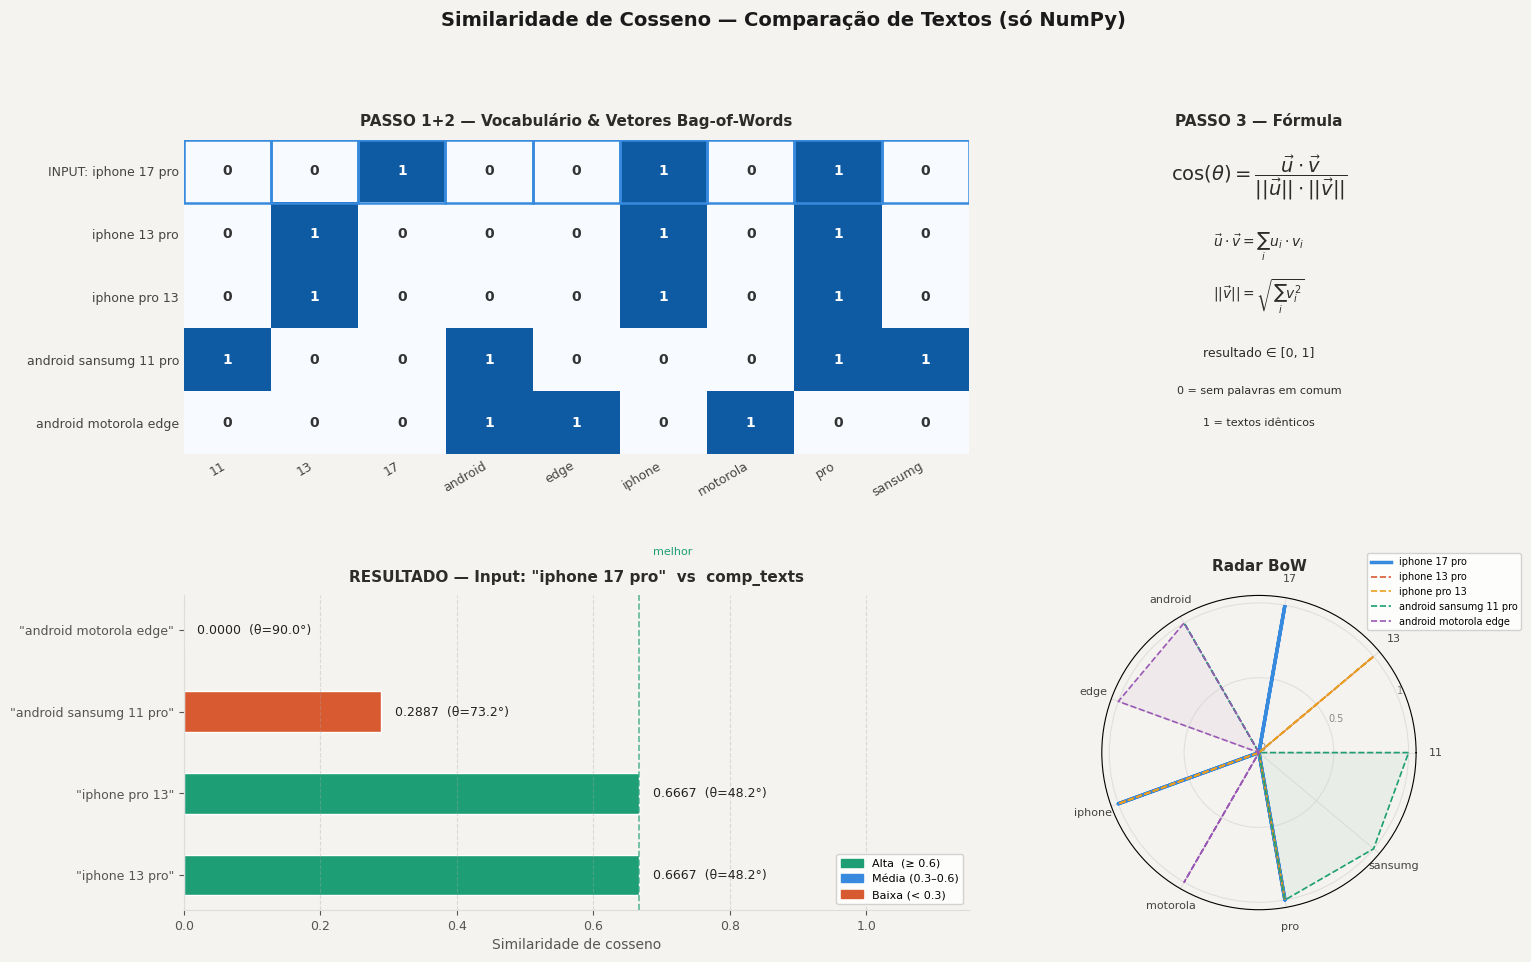

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZAÇÃO — 4 painéis
# ══════════════════════════════════════════════════════════════════════════════
BG      = "#f5f3ef"
CINPUT  = "#378ADD"

def bar_color(s):
    if s >= 0.6: return "#1D9E75"
    if s >= 0.3: return "#378ADD"
    return "#D85A30"
bar_colors = [bar_color(s) for s in sims]

fig = plt.figure(figsize=(16, 10), facecolor=BG)
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)


# Painel 1 — Heatmap BoW
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(BG)
mat = np.array([vectors[t] for t in all_texts])
ax1.imshow(mat, aspect="auto", cmap="Blues", vmin=0, vmax=1.2)
ax1.set_xticks(range(len(vocab)))
ax1.set_xticklabels(vocab, fontsize=9, rotation=30, ha="right", color="#444")
ax1.set_yticks(range(len(all_texts)))
ax1.set_yticklabels([f"INPUT: {input_text}"] + comp_texts, fontsize=9, color="#444")
for (r, c), val in np.ndenumerate(mat):
    ax1.text(c, r, int(val), ha="center", va="center", fontsize=10,
             fontweight="bold", color="white" if val >= 0.8 else "#333")
ax1.set_title("PASSO 1+2 — Vocabulário & Vetores Bag-of-Words",
              fontsize=11, fontweight="bold", color="#2c2c2a", pad=10)
ax1.tick_params(length=0)
for sp in ax1.spines.values(): sp.set_visible(False)
for x in range(len(vocab)):
    ax1.add_patch(plt.Rectangle((x-0.5,-0.5),1,1,fill=False,edgecolor=CINPUT,lw=1.8,zorder=3))

# Painel 2 — Fórmula
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(BG); ax2.axis("off")
ax2.set_title("PASSO 3 — Fórmula", fontsize=11, fontweight="bold", color="#2c2c2a", pad=10)
for x, y, txt, fs in [
    (0.5, 0.88, r"$\cos(\theta)=\dfrac{\vec{u}\cdot\vec{v}}{||\vec{u}||\cdot||\vec{v}||}$", 14),
    (0.5, 0.66, r"$\vec{u}\cdot\vec{v}=\sum_i u_i\cdot v_i$", 10),
    (0.5, 0.50, r"$||\vec{v}||=\sqrt{\sum_i v_i^2}$", 10),
    (0.5, 0.32, "resultado ∈ [0, 1]", 9),
    (0.5, 0.20, "0 = sem palavras em comum", 8),
    (0.5, 0.10, "1 = textos idênticos", 8),
]:
    ax2.text(x, y, txt, ha="center", va="center", fontsize=fs,
             color="#2c2c2a", transform=ax2.transAxes)

# Painel 3 — Barras horizontais
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor(BG)
y_pos = np.arange(len(comp_texts))
bars  = ax3.barh(y_pos, sims, color=bar_colors, height=0.5, edgecolor="white", lw=1.0)
ax3.set_xlim(0, 1.15)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([f'"{c}"' for c in comp_texts], fontsize=9.5, color="#333")
ax3.set_xlabel("Similaridade de cosseno", fontsize=10, color="#555")
ax3.set_title(f'RESULTADO — Input: "{input_text}"  vs  comp_texts',
              fontsize=11, fontweight="bold", color="#2c2c2a", pad=10)
ax3.grid(axis="x", linestyle="--", alpha=0.35, color="#aaa")
ax3.tick_params(labelsize=9, colors="#555")
for sp in ["top","right"]: ax3.spines[sp].set_visible(False)
for sp in ["left","bottom"]: ax3.spines[sp].set_edgecolor("#ddd")
for bar, (comp, sim, angle) in zip(bars, results):
    ax3.text(sim+0.02, bar.get_y()+bar.get_height()/2,
             f"{sim:.4f}  (θ={angle:.1f}°)", va="center", fontsize=9, fontweight="500", color="#222")
best_sim = max(sims)
ax3.axvline(best_sim, color="#1D9E75", linestyle="--", lw=1.2, alpha=0.7)
ax3.text(best_sim+0.02, len(comp_texts)-0.08, "melhor", fontsize=8, color="#1D9E75")
ax3.legend(handles=[
    mpatches.Patch(color="#1D9E75", label="Alta  (≥ 0.6)"),
    mpatches.Patch(color="#378ADD", label="Média (0.3–0.6)"),
    mpatches.Patch(color="#D85A30", label="Baixa (< 0.3)"),
], fontsize=8, loc="lower right", framealpha=0.85, edgecolor="#ccc")

# Painel 4 — Radar
ax4 = fig.add_subplot(gs[1, 2], polar=True)
ax4.set_facecolor(BG)
ax4.set_title("Radar BoW", fontsize=11, fontweight="bold", color="#2c2c2a", pad=18)
N = len(vocab)
angles   = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles_c = angles + angles[:1]
radar_colors = [CINPUT, "#D85A30","#E8A020","#1D9E75","#9B59B6"]
radar_lw     = [2.5, 1.2, 1.2, 1.2, 1.2]
for i, text in enumerate([input_text]+comp_texts):
    vals = vectors[text].tolist() + [vectors[text][0]]
    ax4.plot(angles_c, vals, color=radar_colors[i], lw=radar_lw[i],
             linestyle="-" if i==0 else "--", label=text)
    ax4.fill(angles_c, vals, alpha=0.06, color=radar_colors[i])
ax4.set_xticks(angles)
ax4.set_xticklabels(vocab, fontsize=8, color="#444")
ax4.set_yticks([0,0.5,1]); ax4.set_yticklabels(["0","0.5","1"], fontsize=7, color="#888")
ax4.grid(color="#ccc", alpha=0.5)
ax4.legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.35,1.15),
           framealpha=0.85, edgecolor="#ccc")

plt.suptitle("Similaridade de Cosseno — Comparação de Textos (só NumPy)",
             fontsize=14, fontweight="bold", y=1.01, color="#1a1a1a")
plt.savefig("cosine_text_similarity_calc.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
print("\nGráfico salvo!")
plt.show()